# Laboratorio 1 — Reconocimiento de animales a partir de audio (multi-label)

**Curso:** Deep Learning — Maestría en Data Science & AI, UTEC · **Grupo 2 (Sección 1):** Henry Godino, David Choque, Bryan Montoya

**Paper implementado:** Duan, L., Yang, L., Niu, D., Guo, Y., & Gu, Y. (2026). *Multi-grained detail-enhanced and patch-aware network based on bird sound recognition* (**MEP-Net**). Engineering Applications of Artificial Intelligence, 172, 114274. https://doi.org/10.1016/j.engappai.2026.114274

---

## 1. Resumen del método (MEP-Net)

MEP-Net reconoce sonidos de aves a partir de **espectrogramas log-Mel** y se compone de tres piezas:

1. **Backbone D-TDNN** (Densely-connected Time Delay Neural Network): capas TDNN (conv1d dilatadas sobre el tiempo) con *conexiones densas* estilo DenseNet — cada capa recibe la concatenación de todas las anteriores — y cuellos de botella FNN (conv1d k=1) que reducen parámetros. Captura dependencias temporales a múltiples contextos y termina en **Statistics Pooling** (media + desviación estándar en el tiempo) que produce un *x-vector* a nivel de clip.
2. **MDEConv** (Multi-grained Detail-enhanced Convolution): fusiona una convolución ordinaria con **cuatro convoluciones diferenciales** — Central (CDC), Angular/diagonal (ADC), Horizontal (HDC) y Vertical (VDC) — que en vez de sumar intensidades ponderan **gradientes locales** `x(p0+pn) − x(p0)` (idea tomada de LBP). Un parámetro θ balancea intensidad vs. gradiente (Eq. 9); el paper encuentra el óptimo en **θ_CDC = θ_ADC = 0.8** (Fig. 9). Esto realza los detalles finos del canto frente al ruido ambiental.
3. **BPAM** (Branch Patch-aware Attention Module): módulo multi-rama con (a) rama **serial** de convoluciones, (b) ramas **patch-aware** con parches de tamaño **p=2 (local)** y **p=4 (global)** que ponderan parches vía MLP + softmax y los filtran por **similitud coseno** con un *embedding* de tarea aprendible (Eq. 10), y (c) atención **CBAM** (canal + espacial). Captura características multi-escala y suprime parches ruidosos.

Resultados del paper: 96.29 % (Birdsdata), 86.51 % (BirdCLEF 2022, acc-47) y 97.40 % (UrbanSound8k).

## 2. Adaptaciones al problema del laboratorio

El paper resuelve clasificación **single-label** (softmax + cross-entropy). Nuestro dataset (grabaciones de la Amazonía, 3 s, 22.05 kHz, mono) es **multi-label a nivel de clip** (0, 1 o varias de 42 especies). Adaptaciones realizadas (todas señaladas también en el código):

| # | Componente | Paper | Nuestra adaptación | Justificación |
|---|-----------|-------|--------------------|---------------|
| 1 | Capa de salida | softmax, 20/47/10 clases | **42 logits + sigmoid** | multi-label: las clases no son mutuamente excluyentes |
| 2 | Pérdida | cross-entropy | **BCEWithLogitsLoss** | pérdida estándar multi-label; estable numéricamente |
| 3 | Métricas | accuracy, precision, recall, F1 (single-label) | **F1 macro/micro, mAP (AP macro), precision/recall por clase** | accuracy simple no es informativa en multi-label |
| 4 | Predicción temporal → clip | Statistics Pooling | se **mantiene** | ya agrega la secuencia temporal en una predicción por grabación |
| 5 | Interfaz 2D→1D (MDEConv/BPAM son 2D, D-TDNN es 1D) | no detallada en el paper | **pooling adaptativo en frecuencia (128→4 bandas) y aplanado canales×bandas como features por frame** | preserva información tiempo-frecuencia con costo bajo; decisión documentada |
| 6 | Entrada | Mel 128 bandas, FFT 2048 | igual (sr=22050, hop=512, **128×128**) | misma representación del paper, T recortado a 128 frames (~3 s) |
| 7 | Épocas | 200 | configurable (por defecto 60 + early stopping) | límite de cómputo (GPU 4 GB); el modelo converge mucho antes |

> **Semilla utilizada: 42** (split 80/20, inicialización y baraje).


---
## 3. Configuración e imports

**Instrucciones de ejecución** (Windows + GPU):
```
pip install torch --index-url https://download.pytorch.org/whl/cu121
pip install librosa soundfile scikit-learn pandas matplotlib tqdm
```
Editar `DATA_DIR` si el dataset está en otra ruta. El notebook corre completo con *Run All*: entrena MEP-Net, las 2 variantes de la ablación, genera `predicciones_test.csv` y guarda los pesos en `checkpoints/`.

In [6]:
import os, math, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             average_precision_score, hamming_loss)
warnings.filterwarnings("ignore")

# ----------------------------- CONFIG -----------------------------
SEED        = 42          # semilla del split 80/20 y de la inicialización
SR          = 22050       # frecuencia de muestreo del dataset
N_FFT       = 2048        # FFT como en el paper (Sección 2.3)
HOP         = 512
N_MELS      = 128         # 128 filtros Mel como en el paper
N_FRAMES    = 128         # ~3 s -> recortamos/rellenamos a 128 frames
N_CLASSES   = 42
BATCH_SIZE  = 32          # batch 32 como en el paper (Sección 4.1)
LR          = 1e-4        # Adam lr=1e-4 como en el paper
EPOCHS      = 60          # paper usa 200; reducido por cómputo (early stopping)
ABLA_EPOCHS = 30          # épocas para las variantes de la ablación
PATIENCE    = 12          # early stopping sobre mAP de validación
THRESHOLD   = 0.5         # umbral inicial de decisión (luego se ajusta en val)

# Rutas candidatas al dataset (editar si es necesario)
_CANDIDATES = [
    Path(r"C:\Users\hgodino.INACONS\Desktop\UTEC MAESTRIA\Ciclo5\Deep Learning\Laboratorios\Laboratorio 1\data"),
    Path("./data"), Path("../data"), Path("./data_synth"),
]
DATA_DIR = next((p for p in _CANDIDATES if (p / "train.csv").exists()), _CANDIDATES[0])
TRAIN_DIR, TEST_DIR, TRAIN_CSV = DATA_DIR / "train", DATA_DIR / "test", DATA_DIR / "train.csv"
CKPT_DIR = Path("./checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("./mel_cache"); CACHE_DIR.mkdir(exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dataset: {DATA_DIR.resolve()}")
print(f"Device : {DEVICE}", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

Dataset: C:\Users\hgodino.INACONS\Desktop\UTEC MAESTRIA\Ciclo5\Deep Learning\Laboratorios\Laboratorio 1\data
Device : cuda NVIDIA RTX A2000 Laptop GPU


---
## 4. Carga y exploración de los datos

`train.csv`: la primera columna es el nombre del archivo y las 42 restantes indican presencia/ausencia (0/1) de cada especie.

In [7]:
df = pd.read_csv(TRAIN_CSV)
FILE_COL = df.columns[0]
CLASS_NAMES = list(df.columns[1:])
assert len(CLASS_NAMES) == N_CLASSES, f"Se esperaban 42 clases, hay {len(CLASS_NAMES)}"
labels_mat = df[CLASS_NAMES].values.astype(np.float32)

n_por_clip = labels_mat.sum(axis=1)
print(f"Grabaciones de entrenamiento : {len(df)}")
print(f"Archivos de test             : {len(list(TEST_DIR.glob('*.wav')))}")
print(f"Etiquetas por clip -> media {n_por_clip.mean():.2f} | min {int(n_por_clip.min())} | max {int(n_por_clip.max())}")
print(f"Clips sin ninguna especie    : {(n_por_clip==0).sum()} ({100*(n_por_clip==0).mean():.1f}%)")
df.head()

Grabaciones de entrenamiento : 62191
Archivos de test             : 31187
Etiquetas por clip -> media 1.51 | min 0 | max 8
Clips sin ninguna especie    : 22504 (36.2%)


,filename,SPHSUR,BOABIS,SCIPER,DENNAH,LEPLAT,RHIICT,BOALEP,BOAFAB,PHYCUV,...,SCINAS,LEPNOT,ADEMAR,BOAALM,PHYDIS,RHIORN,LEPFLA,SCIRIZ,DENELE,SCIALT
0,INCT20955_20190909_050000_0_3.wav,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,INCT20955_20190909_050000_1_4.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,INCT20955_20190909_050000_2_5.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,INCT20955_20190909_050000_3_6.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,INCT20955_20190909_050000_4_7.wav,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


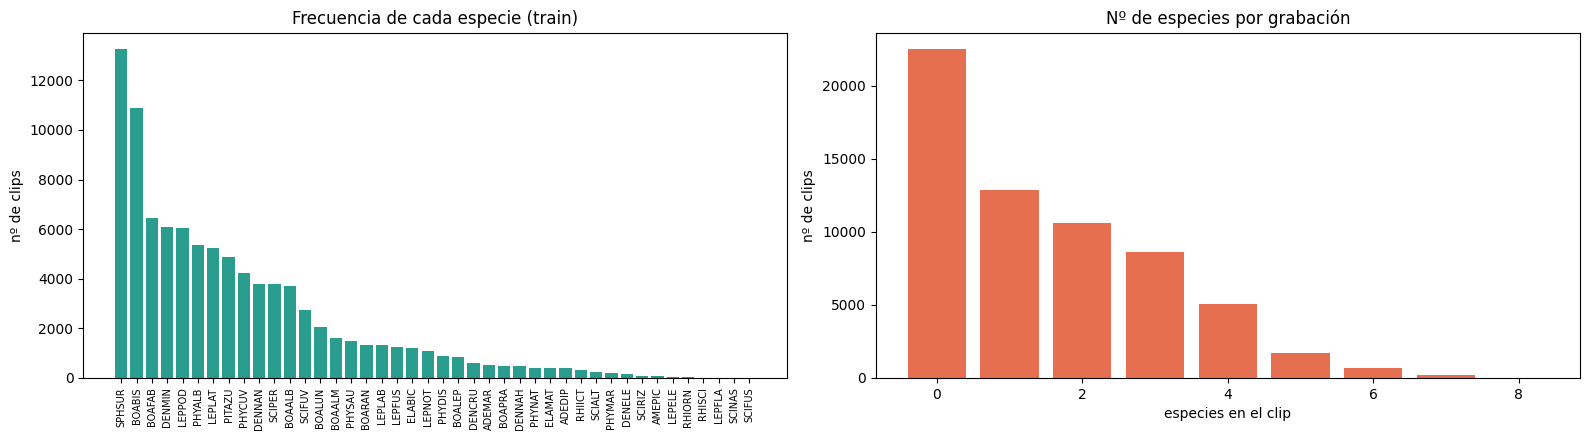

Clases con <10 ejemplos: ['SCIFUS', 'SCINAS', 'LEPFLA']


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
counts = labels_mat.sum(axis=0)
order = np.argsort(counts)[::-1]
axes[0].bar(range(N_CLASSES), counts[order], color="#2a9d8f")
axes[0].set_xticks(range(N_CLASSES))
axes[0].set_xticklabels([CLASS_NAMES[i] for i in order], rotation=90, fontsize=7)
axes[0].set_title("Frecuencia de cada especie (train)"); axes[0].set_ylabel("nº de clips")
vals, cnts = np.unique(n_por_clip.astype(int), return_counts=True)
axes[1].bar(vals, cnts, color="#e76f51")
axes[1].set_title("Nº de especies por grabación"); axes[1].set_xlabel("especies en el clip"); axes[1].set_ylabel("nº de clips")
plt.tight_layout(); plt.show()

print("Clases con <10 ejemplos:", [CLASS_NAMES[i] for i in range(N_CLASSES) if counts[i] < 10])

---
## 5. Representación: espectrograma log-Mel (Sección 2.3 del paper)

Pipeline del paper: pre-énfasis → framing → ventana → FFT (2048) → banco de **128 filtros Mel** → log (Eq. 4). Precalculamos todos los espectrogramas una sola vez y los guardamos en caché (`.npy`) para acelerar las épocas.

In [9]:
def wav_to_logmel(path, pre_emphasis=0.97):
    y, _ = librosa.load(path, sr=SR, mono=True)
    y = np.append(y[0], y[1:] - pre_emphasis * y[:-1])          # (1) pre-énfasis
    mel = librosa.feature.melspectrogram(                        # (2)-(4) framing+ventana+FFT+Mel
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, power=2.0)
    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)   # Eq. (4): log
    # normalización por clip a [0,1] y ajuste a N_FRAMES
    logmel = (logmel - logmel.min()) / (logmel.max() - logmel.min() + 1e-8)
    T = logmel.shape[1]
    if T < N_FRAMES:
        logmel = np.pad(logmel, ((0, 0), (0, N_FRAMES - T)))
    else:
        logmel = logmel[:, :N_FRAMES]
    return logmel                                                # (128, 128)

def get_mel_cached(wav_path, split):
    cache = CACHE_DIR / split / (Path(wav_path).stem + ".npy")
    if cache.exists():
        return np.load(cache)
    cache.parent.mkdir(parents=True, exist_ok=True)
    m = wav_to_logmel(wav_path)
    np.save(cache, m)
    return m

# precálculo con barra de progreso
from tqdm.auto import tqdm
t0 = time.time()
for fn in tqdm(df[FILE_COL], desc="cache train"):
    get_mel_cached(TRAIN_DIR / fn, "train")
test_files = sorted(TEST_DIR.glob("*.wav"))
for p in tqdm(test_files, desc="cache test"):
    get_mel_cached(p, "test")
print(f"Espectrogramas cacheados en {time.time()-t0:.1f}s -> {CACHE_DIR.resolve()}")

cache test: 100%|██████████| 31187/31187 [04:16<00:00, 121.35it/s]

Espectrogramas cacheados en 832.7s -> C:\Users\hgodino.INACONS\Desktop\UTEC MAESTRIA\Ciclo5\Deep Learning\Laboratorios\Laboratorio 1\mel_cache


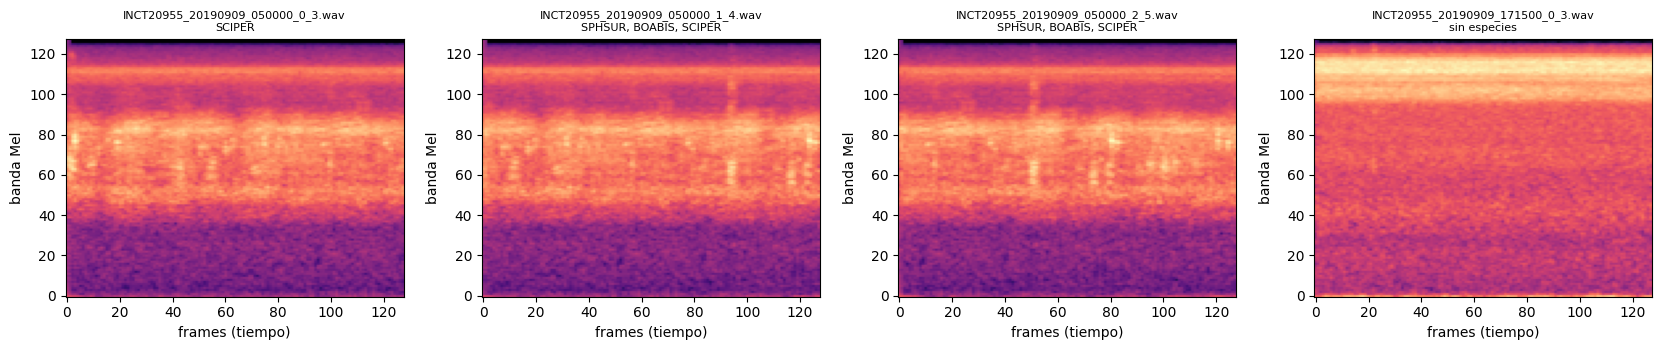

In [10]:
# Visualización de ejemplos
idx_multi = np.where(n_por_clip >= 2)[0][:2] if (n_por_clip >= 2).any() else [0, 1]
idx_none  = np.where(n_por_clip == 0)[0][:1]
idx_one   = np.where(n_por_clip == 1)[0][:1]
show = list(idx_one) + list(idx_multi) + list(idx_none)
fig, axes = plt.subplots(1, len(show), figsize=(4.2*len(show), 3.6))
for ax, i in zip(np.atleast_1d(axes), show):
    m = get_mel_cached(TRAIN_DIR / df[FILE_COL].iloc[i], "train")
    ax.imshow(m, aspect="auto", origin="lower", cmap="magma")
    present = [CLASS_NAMES[j] for j in range(N_CLASSES) if labels_mat[i, j] == 1]
    ax.set_title(f"{df[FILE_COL].iloc[i]}\n{', '.join(present) if present else 'sin especies'}", fontsize=8)
    ax.set_xlabel("frames (tiempo)"); ax.set_ylabel("banda Mel")
plt.tight_layout(); plt.show()

---
## 6. Implementación de MEP-Net

### 6.1 Convoluciones diferenciales y MDEConv (Sección 3.1, Fig. 4)

La convolución diferencial (Eq. 8–9) pondera **gradientes** respecto al píxel central en lugar de intensidades:

$$y(p_0)=\theta\sum_{p_n\in R}\omega(p_n)\,(x(p_0{+}p_n)-x(p_0)) + (1-\theta)\sum_{p_n\in R}\omega(p_n)\,x(p_0{+}p_n)$$

que se implementa eficientemente como `conv(x) − θ·x·Σω` (la suma del kernel actúa como conv 1×1). El vecindario $R$ se restringe con **máscaras binarias 3×3**: CDC (todo), ADC (diagonales), HDC (horizontal = tiempo), VDC (vertical = frecuencia). Usamos **θ_CDC = θ_ADC = 0.8** (óptimo de la Fig. 9) y θ=1 para HDC/VDC (patrón direccional fijo).

In [12]:
class DiffConv2d(nn.Module):
    """Convolución diferencial genérica con máscara direccional y theta adaptable."""

    MASKS = {
        # máscaras 3x3: 1 = posición pertenece al vecindario R
        "cdc": [[1, 1, 1], [1, 1, 1], [1, 1, 1]],           # central (todo)
        "adc": [[1, 0, 1], [0, 1, 0], [1, 0, 1]],           # angular (diagonales)
        "hdc": [[0, 0, 0], [1, 1, 1], [0, 0, 0]],           # horizontal (eje tiempo)
        "vdc": [[0, 1, 0], [0, 1, 0], [0, 1, 0]],           # vertical (eje frecuencia)
    }

    def __init__(self, in_ch, out_ch, kind="cdc", theta=0.8):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.theta = theta
        mask = torch.tensor(self.MASKS[kind], dtype=torch.float32)
        self.register_buffer("mask", mask.view(1, 1, 3, 3))

    def forward(self, x):
        w = self.conv.weight * self.mask          # restringe el kernel al vecindario R
        y = F.conv2d(x, w, padding=1)             # sum_w x(p0+pn)
        if self.theta > 0:
            # término - theta * x(p0) * sum(w): equivale a conv 1x1 con la suma del kernel
            w_sum = w.sum(dim=(2, 3), keepdim=True)   # (out,in,1,1)
            y = y - self.theta * F.conv2d(x, w_sum)
        return y


class DEConv(nn.Module):
    """Bloque de fusión: conv ordinaria + CDC + ADC + HDC + VDC en paralelo (Fig. 4).
    theta_cdc = theta_adc = 0.8 (Fig. 9 del paper); HDC/VDC usan patrón fijo (theta=1)."""

    def __init__(self, ch, theta_cdc=0.8, theta_adc=0.8, use_diff=True):
        super().__init__()
        self.vanilla = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.use_diff = use_diff
        if use_diff:
            self.cdc = DiffConv2d(ch, ch, "cdc", theta=theta_cdc)
            self.adc = DiffConv2d(ch, ch, "adc", theta=theta_adc)
            self.hdc = DiffConv2d(ch, ch, "hdc", theta=1.0)
            self.vdc = DiffConv2d(ch, ch, "vdc", theta=1.0)

    def forward(self, x):
        y = self.vanilla(x)
        if self.use_diff:
            y = y + self.cdc(x) + self.adc(x) + self.hdc(x) + self.vdc(x)
        return y


class MDEConv(nn.Module):
    """Módulo MDEConv completo (Fig. 4):
    conv2d(k3)+BN -> 3x conv2d(k3) -> BN -> DEConv (fusión diferencial)."""

    def __init__(self, in_ch=1, ch=32, use_diff=True):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
            nn.ReLU(inplace=True),
        )
        self.deconv = DEConv(ch, use_diff=use_diff)
        self.bn_out = nn.BatchNorm2d(ch)

    def forward(self, x):
        x = self.stem(x)
        return F.relu(self.bn_out(self.deconv(x)))


### 6.2 BPAM (Sección 3.2, Fig. 6)

Tres ramas en paralelo: **serial** (convoluciones 3×3 encadenadas), **patch local (p=2)** y **patch global (p=4)**. Cada rama patch-aware: partición en parches → mean-pool de canal → proyección a C → MLP + softmax espacial (pesos por parche) → **selección por similitud coseno** con un embedding de tarea aprendible ξ (Eq. 10: $\hat t_i = P\cdot sim(t_i,\xi)\cdot t_i$) → upsample bilinear → conv 1×1. La fusión pasa por **CBAM** (atención de canal + espacial), dropout, BN y ReLU.

In [13]:
class PatchAware(nn.Module):
    """Rama patch-aware: divide el mapa en parches p x p, pondera cada parche
    con un MLP + softmax espacial y selecciona características por similitud
    coseno con un embedding de tarea aprendible (Eq. 10)."""

    def __init__(self, ch, p):
        super().__init__()
        self.p = p
        self.to_channel = nn.Linear(p * p, ch)      # p*p -> C ("mapped to channel number C")
        self.mlp = nn.Sequential(                    # MLP no lineal (Linear, Linear)
            nn.Linear(ch, ch),
            nn.ReLU(inplace=True),
            nn.Linear(ch, ch),
        )
        self.task_embed = nn.Parameter(torch.randn(ch) * 0.02)  # xi (embedding de tarea)
        self.proj = nn.Linear(ch, ch, bias=False)                # P (Eq. 10)
        self.out_conv = nn.Conv2d(ch, ch, 1, bias=False)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.p
        Hp, Wp = H // p, W // p
        # partición en parches: (B, C, Hp, p, Wp, p) -> (B, N, p*p, C), N = Hp*Wp
        t = x.view(B, C, Hp, p, Wp, p).permute(0, 2, 4, 3, 5, 1).reshape(B, Hp * Wp, p * p, C)
        # mean-pooling sobre el canal -> (B, N, p*p) y proyección a C
        t = self.to_channel(t.mean(dim=3))           # (B, N, C)
        # pesos espaciales: MLP + softmax sobre la dimensión espacial N
        w = F.softmax(self.mlp(t), dim=1)            # (B, N, C)
        t = w * t                                    # parches ponderados t_i
        # selección por similitud coseno con el embedding de tarea xi (Eq. 10)
        sim = F.cosine_similarity(t, self.task_embed.view(1, 1, -1), dim=-1)  # (B, N)
        h = self.proj(t) * sim.unsqueeze(-1)         # h_i = P * sim(t_i, xi) * t_i
        # restaurar forma espacial y upsample bilinear a (H, W)
        h = h.permute(0, 2, 1).reshape(B, C, Hp, Wp)
        h = F.interpolate(h, size=(H, W), mode="bilinear", align_corners=False)
        return self.out_conv(h)


class ChannelAttention(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(ch, ch // r), nn.ReLU(inplace=True), nn.Linear(ch // r, ch)
        )

    def forward(self, x):
        avg = self.mlp(x.mean(dim=(2, 3)))
        mx = self.mlp(x.amax(dim=(2, 3)))
        return x * torch.sigmoid(avg + mx).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        s = torch.cat([x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)], dim=1)
        return x * torch.sigmoid(self.conv(s))


class BPAM(nn.Module):
    """BPAM (Fig. 6): rama serial de convoluciones + ramas patch-aware locales
    (p=2) y globales (p=4) + atención CBAM (canal + espacial)."""

    def __init__(self, ch, p_local=2, p_global=4, dropout=0.1):
        super().__init__()
        # rama serial de convoluciones
        self.conv_a = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.conv_b = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
        )
        # ramas patch-aware
        self.conv1x1 = nn.Conv2d(ch, ch, 1, bias=False)
        self.patch_local = PatchAware(ch, p_local)    # p=2: detalles locales
        self.patch_global = PatchAware(ch, p_global)  # p=4: contexto global
        # atención CBAM + regularización
        self.cbam_c = ChannelAttention(ch)
        self.cbam_s = SpatialAttention()
        self.dropout = nn.Dropout2d(dropout)
        self.bn = nn.BatchNorm2d(ch)

    def forward(self, x):
        a = self.conv_a(x)
        serial = a + self.conv_b(a)                      # rama serial
        z = self.conv1x1(x)
        patches = self.patch_local(z) + self.patch_global(z)  # ramas de parches
        y = serial + patches                              # fusión aditiva multi-escala
        y = self.cbam_s(self.cbam_c(y))                   # CBAM
        y = self.dropout(y)
        return F.relu(self.bn(y))


### 6.3 Backbone D-TDNN y modelo completo (Fig. 1, 7)

Cada capa D-TDNN: FNN cuello de botella (conv1d k=1 → 2g) + capa TDNN (conv1d k=3 dilatada → g=64) con **conexión densa** ($d^l = D^l([d^0,\dots,d^{l-1}])$, Eq. 1). Estructura: stem → **6 bloques** → transición → **12 bloques** → Statistics Pooling → FC → cabeza de **42 logits** (adaptación multi-label #1). Los flags `use_mdeconv` / `use_bpam` construyen las variantes de la **ablación** (Tabla 4 del paper).

In [14]:
class DTDNNLayer(nn.Module):
    """Capa D-TDNN: FNN cuello de botella (conv1d k=1 -> 2g) + capa TDNN
    (conv1d k=3 dilatada -> g) con conexión densa (concat)."""

    def __init__(self, in_ch, growth=64, dilation=1):
        super().__init__()
        bottleneck = 2 * growth
        self.fnn = nn.Sequential(
            nn.BatchNorm1d(in_ch), nn.ReLU(inplace=True),
            nn.Conv1d(in_ch, bottleneck, 1, bias=False),
        )
        self.tdnn = nn.Sequential(
            nn.BatchNorm1d(bottleneck), nn.ReLU(inplace=True),
            nn.Conv1d(bottleneck, growth, 3, padding=dilation, dilation=dilation, bias=False),
        )

    def forward(self, x):
        return torch.cat([x, self.tdnn(self.fnn(x))], dim=1)  # d^l = D([d^0..d^{l-1}])


class DTDNNBlock(nn.Module):
    def __init__(self, in_ch, n_layers, growth=64):
        super().__init__()
        layers, ch = [], in_ch
        for i in range(n_layers):
            layers.append(DTDNNLayer(ch, growth, dilation=(i % 3) + 1))
            ch += growth
        self.block = nn.Sequential(*layers)
        self.out_ch = ch

    def forward(self, x):
        return self.block(x)


class StatsPooling(nn.Module):
    """Statistics pooling: concatena media y desviación estándar sobre el tiempo
    (convierte la secuencia temporal en un x-vector a nivel de clip — esto es
    lo que agrega las predicciones temporales en UNA predicción por grabación)."""

    def forward(self, x):
        return torch.cat([x.mean(dim=2), x.std(dim=2)], dim=1)


# ---------------------------------------------------------------------
# 4. MEP-Net completo, adaptado a multi-label
# ---------------------------------------------------------------------
class MEPNet(nn.Module):
    """
    use_mdeconv / use_bpam permiten construir las variantes de la ablación
    (Tabla 4 del paper): D-TDNN base, D-TDNN+MDEConv, MEP-Net completo.
    """

    def __init__(self, n_classes=42, n_mels=128, ch2d=32, growth=64,
                 blocks=(6, 12), emb_dim=256, freq_bins_out=4,
                 use_mdeconv=True, use_bpam=True, use_diff=True):
        super().__init__()
        self.use_mdeconv = use_mdeconv
        self.use_bpam = use_bpam

        if use_mdeconv:
            self.mdeconv = MDEConv(1, ch2d, use_diff=use_diff)
        else:
            # variante base: una sola conv 2D ligera para igualar canales
            self.mdeconv = nn.Sequential(
                nn.Conv2d(1, ch2d, 3, padding=1, bias=False),
                nn.BatchNorm2d(ch2d), nn.ReLU(inplace=True),
            )
        if use_bpam:
            self.bpam = BPAM(ch2d)

        # Adaptación 2D -> 1D: pooling de frecuencia y aplanado de canales.
        # (Decisión de diseño: el paper no detalla la conversión; agregamos la
        # frecuencia con pooling adaptativo a freq_bins_out bandas y usamos
        # ch2d*freq_bins_out como dimensión de características por frame.)
        self.freq_pool = nn.AdaptiveAvgPool2d((freq_bins_out, None))
        feat_dim = ch2d * freq_bins_out

        # TDNN stem ("TDNN-block": conv1d + BN + ReLU)
        self.stem = nn.Sequential(
            nn.Conv1d(feat_dim, 128, 5, padding=2, bias=False),
            nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        )
        # 6x D-TDNN
        self.block1 = DTDNNBlock(128, blocks[0], growth)
        # transición: BN -> ReLU -> conv1d (reduce canales a la mitad)
        self.trans = nn.Sequential(
            nn.BatchNorm1d(self.block1.out_ch), nn.ReLU(inplace=True),
            nn.Conv1d(self.block1.out_ch, self.block1.out_ch // 2, 1, bias=False),
        )
        # 12x D-TDNN
        self.block2 = DTDNNBlock(self.block1.out_ch // 2, blocks[1], growth)

        self.pool = StatsPooling()
        pooled = self.block2.out_ch * 2
        self.fc1 = nn.Linear(pooled, emb_dim)
        self.head = nn.Sequential(
            nn.ReLU(inplace=True), nn.BatchNorm1d(emb_dim),
            nn.Linear(emb_dim, n_classes),   # 42 logits -> sigmoid (multi-label)
        )

    def forward(self, x):                    # x: (B, 1, n_mels, T)
        x = self.mdeconv(x)
        if self.use_bpam:
            x = self.bpam(x)
        x = self.freq_pool(x)                # (B, C, F', T)
        B, C, Fb, T = x.shape
        x = x.reshape(B, C * Fb, T)          # características por frame
        x = self.stem(x)
        x = self.block1(x)
        x = self.trans(x)
        x = self.block2(x)
        x = self.pool(x)                     # x-vector a nivel de clip
        x = self.fc1(x)
        return self.head(x)                  # logits (usar BCEWithLogitsLoss)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [15]:
# Verificación de forward y nº de parámetros de las 3 variantes
for name, kw in [("D-TDNN (base)", dict(use_mdeconv=False, use_bpam=False)),
                 ("D-TDNN + MDEConv", dict(use_mdeconv=True, use_bpam=False)),
                 ("MEP-Net (completo)", dict(use_mdeconv=True, use_bpam=True))]:
    m = MEPNet(**kw)
    out = m(torch.randn(2, 1, N_MELS, N_FRAMES))
    print(f"{name:22s} salida {tuple(out.shape)}  parámetros {count_params(m)/1e6:.3f}M")
del m

D-TDNN (base)          salida (2, 42)  parámetros 2.371M
D-TDNN + MDEConv       salida (2, 42)  parámetros 2.444M
MEP-Net (completo)     salida (2, 42)  parámetros 2.483M


### 6.4 Visualización del efecto de las convoluciones diferenciales (réplica de la Fig. 5)

Aplicamos cada convolución diferencial (kernel promedio, sin entrenar) sobre un espectrograma real para ver qué gradientes captura cada dirección.

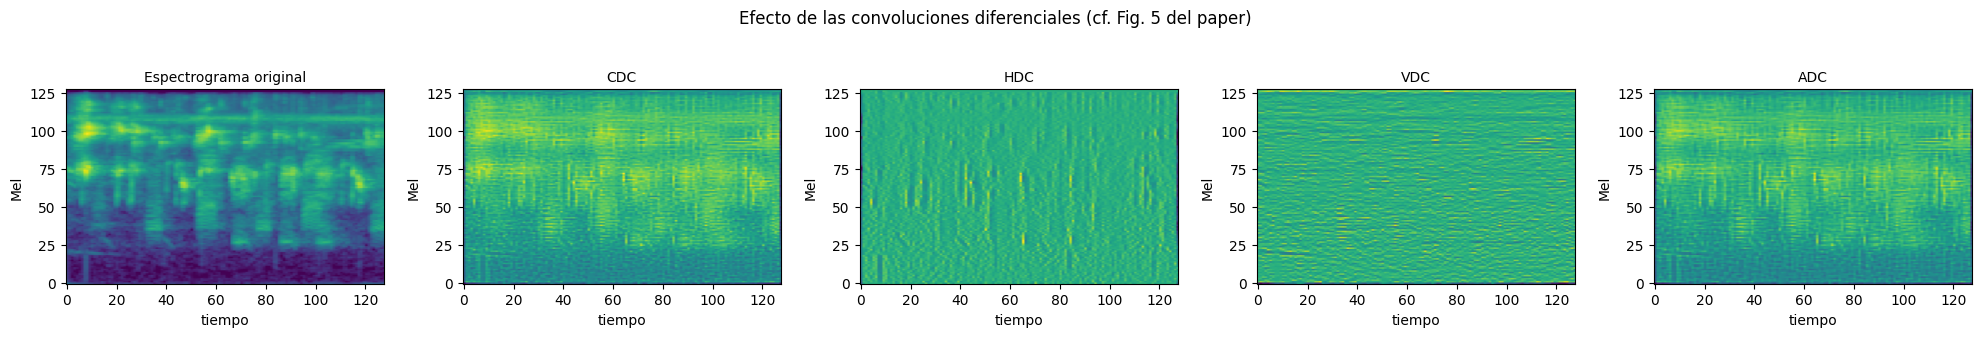

In [16]:
i0 = int(np.argmax(n_por_clip))     # clip con más especies
mel0 = torch.tensor(get_mel_cached(TRAIN_DIR / df[FILE_COL].iloc[i0], "train"))[None, None]
outs = {"Espectrograma original": mel0[0, 0].numpy()}
with torch.no_grad():
    for kind in ["cdc", "hdc", "vdc", "adc"]:
        dc = DiffConv2d(1, 1, kind, theta=0.8 if kind in ("cdc", "adc") else 1.0)
        nn.init.constant_(dc.conv.weight, 1/9)
        outs[kind.upper()] = dc(mel0)[0, 0].numpy()
fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))
for ax, (k, v) in zip(axes, outs.items()):
    ax.imshow(v, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(k, fontsize=10); ax.set_xlabel("tiempo"); ax.set_ylabel("Mel")
plt.suptitle("Efecto de las convoluciones diferenciales (cf. Fig. 5 del paper)", y=1.04)
plt.tight_layout(); plt.show()

---
## 7. Dataset de PyTorch, augmentación y split 80/20 (semilla 42)

Augmentación ligera solo en entrenamiento (enmascaramiento tiempo/frecuencia estilo SpecAugment, implementado a mano): ayuda a la robustez frente a ruido sin alterar la propuesta del paper.

In [17]:
class BirdClips(Dataset):
    def __init__(self, files, labels=None, split="train", augment=False):
        self.files, self.labels, self.split, self.augment = files, labels, split, augment
    def __len__(self):
        return len(self.files)
    def _spec_augment(self, m):
        m = m.copy()
        for _ in range(2):                                   # 2 máscaras de frecuencia
            f0 = np.random.randint(0, N_MELS - 12); m[f0:f0 + np.random.randint(4, 12), :] = 0
        for _ in range(2):                                   # 2 máscaras de tiempo
            t0 = np.random.randint(0, N_FRAMES - 16); m[:, t0:t0 + np.random.randint(4, 16)] = 0
        return m
    def __getitem__(self, i):
        m = get_mel_cached(self.files[i], self.split)
        if self.augment:
            m = self._spec_augment(m)
        x = torch.from_numpy(m)[None]                        # (1, 128, 128)
        if self.labels is None:
            return x, Path(self.files[i]).name
        return x, torch.from_numpy(self.labels[i])

# ---------- split 80/20 con SEED=42 ----------
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(df))
n_val = int(round(0.2 * len(df)))
val_idx, tr_idx = perm[:n_val], perm[n_val:]
tr_files  = [TRAIN_DIR / f for f in df[FILE_COL].iloc[tr_idx]]
val_files = [TRAIN_DIR / f for f in df[FILE_COL].iloc[val_idx]]
y_tr, y_val = labels_mat[tr_idx], labels_mat[val_idx]
print(f"train: {len(tr_files)} clips | val: {len(val_files)} clips (semilla {SEED})")

NUM_WORKERS = 0 if os.name == "nt" else 2      # 0 en Windows evita problemas de multiprocessing
dl_tr  = DataLoader(BirdClips(tr_files, y_tr, "train", augment=True),
                    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
dl_val = DataLoader(BirdClips(val_files, y_val, "train"),
                    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

train: 49753 clips | val: 12438 clips (semilla 42)


---
## 8. Entrenamiento y métricas multi-label

Como en el paper: **Adam, lr = 1e-4, batch = 32**. Pérdida adaptada a multi-label: **BCEWithLogitsLoss** (adaptación #2). Métricas (adaptación #3): **mAP** (average precision macro — no depende del umbral), **F1 macro/micro**, precision/recall macro y hamming loss. Early stopping sobre el mAP de validación. Se usa AMP (precisión mixta) si hay GPU — importante para los 4 GB de VRAM.

In [18]:
def compute_metrics(y_true, y_prob, thr=THRESHOLD):
    y_pred = (y_prob >= thr).astype(int)
    valid = y_true.sum(axis=0) > 0            # AP indefinido para clases sin positivos en val
    return {
        "mAP":       average_precision_score(y_true[:, valid], y_prob[:, valid], average="macro"),
        "F1_macro":  f1_score(y_true, y_pred, average="macro",  zero_division=0),
        "F1_micro":  f1_score(y_true, y_pred, average="micro",  zero_division=0),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":    recall_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming":   hamming_loss(y_true, y_pred),
    }

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); probs, trues, losses = [], [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        losses.append(F.binary_cross_entropy_with_logits(logits, y).item())
        probs.append(torch.sigmoid(logits).cpu().numpy()); trues.append(y.cpu().numpy())
    y_prob, y_true = np.vstack(probs), np.vstack(trues)
    m = compute_metrics(y_true, y_prob); m["loss"] = float(np.mean(losses))
    return m, y_prob, y_true

def train_model(model, name, epochs=EPOCHS, lr=LR):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)          # Adam lr=1e-4 (paper)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=4)
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    crit = nn.BCEWithLogitsLoss()
    hist, best_map, best_ep, wait = [], -1, -1, 0
    ckpt = CKPT_DIR / f"{name}.pt"
    for ep in range(1, epochs + 1):
        model.train(); tr_loss, t0 = 0.0, time.time()
        for x, y in dl_tr:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(DEVICE.type, enabled=(DEVICE.type == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tr_loss += loss.item() * len(x)
        tr_loss /= len(dl_tr.dataset)
        vm, _, _ = evaluate(model, dl_val)
        sched.step(vm["mAP"])
        hist.append({"epoch": ep, "train_loss": tr_loss, **{f"val_{k}": v for k, v in vm.items()}})
        star = ""
        if vm["mAP"] > best_map:
            best_map, best_ep, wait = vm["mAP"], ep, 0
            torch.save(model.state_dict(), ckpt); star = " *"
        else:
            wait += 1
        print(f"[{name}] ep {ep:3d}/{epochs} | loss {tr_loss:.4f} | val_loss {vm['loss']:.4f} | "
              f"mAP {vm['mAP']:.4f} | F1M {vm['F1_macro']:.4f} | F1m {vm['F1_micro']:.4f} | "
              f"{time.time()-t0:.0f}s{star}")
        if wait >= PATIENCE:
            print(f"Early stopping (mejor época: {best_ep}, mAP {best_map:.4f})"); break
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model, pd.DataFrame(hist)

### 8.1 Entrenamiento de MEP-Net completo

In [19]:
set_seed()
mepnet = MEPNet(n_classes=N_CLASSES, use_mdeconv=True, use_bpam=True)
print(f"MEP-Net: {count_params(mepnet)/1e6:.3f}M parámetros")
mepnet, hist_full = train_model(mepnet, "mepnet_full", epochs=EPOCHS)

MEP-Net: 2.483M parámetros
[mepnet_full] ep   1/60 | loss 0.2684 | val_loss 0.1230 | mAP 0.3237 | F1M 0.3177 | F1m 0.6069 | 424s *
[mepnet_full] ep   2/60 | loss 0.0532 | val_loss 0.1107 | mAP 0.3315 | F1M 0.3528 | F1m 0.6324 | 364s *
[mepnet_full] ep   3/60 | loss 0.0394 | val_loss 0.0320 | mAP 0.6530 | F1M 0.5538 | F1m 0.8420 | 362s *
[mepnet_full] ep   4/60 | loss 0.0332 | val_loss 0.0290 | mAP 0.6620 | F1M 0.5751 | F1m 0.8611 | 364s *
[mepnet_full] ep   5/60 | loss 0.0294 | val_loss 0.0318 | mAP 0.6931 | F1M 0.6137 | F1m 0.8673 | 363s *
[mepnet_full] ep   6/60 | loss 0.0270 | val_loss 0.0242 | mAP 0.7077 | F1M 0.6521 | F1m 0.8885 | 364s *
[mepnet_full] ep   7/60 | loss 0.0250 | val_loss 0.0264 | mAP 0.7123 | F1M 0.6639 | F1m 0.8833 | 364s *
[mepnet_full] ep   8/60 | loss 0.0236 | val_loss 0.0273 | mAP 0.7141 | F1M 0.6747 | F1m 0.8804 | 365s *
[mepnet_full] ep   9/60 | loss 0.0221 | val_loss 0.0209 | mAP 0.7787 | F1M 0.7031 | F1m 0.9021 | 365s *
[mepnet_full] ep  10/60 | loss 0.0210

Métricas de validación (MEP-Net, umbral 0.5):
  mAP       : 0.9778
  F1_macro  : 0.8703
  F1_micro  : 0.9622
  precision : 0.8972
  recall    : 0.8505
  hamming   : 0.0027
  loss      : 0.0090


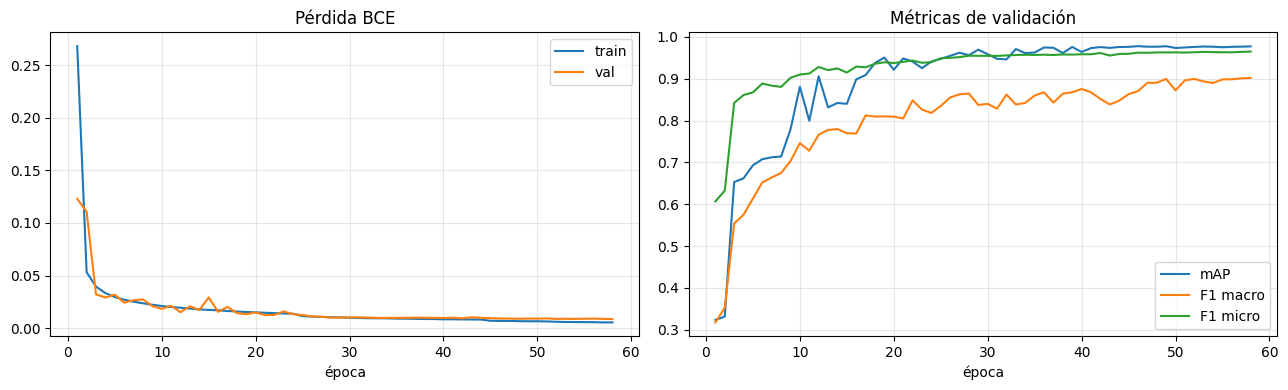

In [20]:
metrics_full, prob_val, y_val_true = evaluate(mepnet, dl_val)
print("Métricas de validación (MEP-Net, umbral 0.5):")
for k, v in metrics_full.items(): print(f"  {k:10s}: {v:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_full["epoch"], hist_full["train_loss"], label="train")
axes[0].plot(hist_full["epoch"], hist_full["val_loss"], label="val")
axes[0].set_title("Pérdida BCE"); axes[0].set_xlabel("época"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(hist_full["epoch"], hist_full["val_mAP"], label="mAP")
axes[1].plot(hist_full["epoch"], hist_full["val_F1_macro"], label="F1 macro")
axes[1].plot(hist_full["epoch"], hist_full["val_F1_micro"], label="F1 micro")
axes[1].set_title("Métricas de validación"); axes[1].set_xlabel("época"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### 8.2 Ajuste del umbral de decisión en validación

En multi-label el umbral 0.5 no suele ser óptimo (clases raras ⇒ probabilidades bajas). Elegimos el **umbral global** que maximiza el F1 macro en validación (sin tocar test).

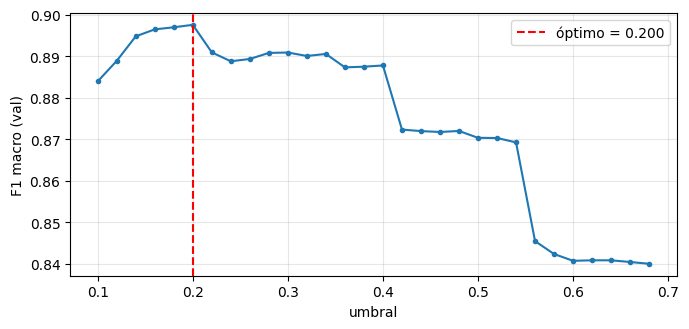

Con umbral 0.200:  F1_macro 0.8975 | F1_micro 0.9574 | precision 0.8945 | recall 0.9037


In [21]:
ths = np.arange(0.10, 0.70, 0.02)
f1s = [f1_score(y_val_true, (prob_val >= t).astype(int), average="macro", zero_division=0) for t in ths]
BEST_TH = float(ths[int(np.argmax(f1s))])
plt.figure(figsize=(7, 3.4)); plt.plot(ths, f1s, "-o", ms=3)
plt.axvline(BEST_TH, color="r", ls="--", label=f"óptimo = {BEST_TH:.3f}")
plt.xlabel("umbral"); plt.ylabel("F1 macro (val)"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
metrics_best = compute_metrics(y_val_true, prob_val, thr=BEST_TH)
print(f"Con umbral {BEST_TH:.3f}:  F1_macro {metrics_best['F1_macro']:.4f} | "
      f"F1_micro {metrics_best['F1_micro']:.4f} | precision {metrics_best['precision']:.4f} | recall {metrics_best['recall']:.4f}")

---
## 9. Ablación (cf. Tabla 4 del paper)

Ablacionamos los **dos módulos propuestos** entrenando, con la misma semilla, datos y configuración:
1. **D-TDNN (base)** — sin MDEConv ni BPAM,
2. **D-TDNN + MDEConv** — solo detalle multi-granular,
3. **MEP-Net completo** — MDEConv + BPAM (ya entrenado arriba).

Esto aísla la contribución de cada componente de la propuesta central.

In [22]:
results = {"MEP-Net (completo)": metrics_full}
hists = {"MEP-Net (completo)": hist_full}
for name, tag, kw in [("D-TDNN (base)", "dtdnn_base", dict(use_mdeconv=False, use_bpam=False)),
                      ("D-TDNN + MDEConv", "dtdnn_mde", dict(use_mdeconv=True, use_bpam=False))]:
    set_seed()
    m = MEPNet(n_classes=N_CLASSES, **kw)
    m, h = train_model(m, tag, epochs=ABLA_EPOCHS)
    results[name], _, _ = evaluate(m, dl_val)
    hists[name] = h
    del m; torch.cuda.empty_cache()

[dtdnn_base] ep   1/30 | loss 0.2818 | val_loss 0.0895 | mAP 0.3073 | F1M 0.2433 | F1m 0.6002 | 161s *
[dtdnn_base] ep   2/30 | loss 0.0623 | val_loss 0.0598 | mAP 0.5009 | F1M 0.4163 | F1m 0.7179 | 126s *
[dtdnn_base] ep   3/30 | loss 0.0483 | val_loss 0.0395 | mAP 0.5871 | F1M 0.4600 | F1m 0.7839 | 132s *
[dtdnn_base] ep   4/30 | loss 0.0423 | val_loss 0.0401 | mAP 0.5953 | F1M 0.4553 | F1m 0.7913 | 138s *
[dtdnn_base] ep   5/30 | loss 0.0382 | val_loss 0.0334 | mAP 0.6485 | F1M 0.5197 | F1m 0.8229 | 147s *
[dtdnn_base] ep   6/30 | loss 0.0351 | val_loss 0.0326 | mAP 0.6695 | F1M 0.5486 | F1m 0.8391 | 134s *
[dtdnn_base] ep   7/30 | loss 0.0329 | val_loss 0.0282 | mAP 0.7481 | F1M 0.6268 | F1m 0.8594 | 142s *
[dtdnn_base] ep   8/30 | loss 0.0312 | val_loss 0.0261 | mAP 0.7975 | F1M 0.5991 | F1m 0.8652 | 140s *
[dtdnn_base] ep   9/30 | loss 0.0295 | val_loss 0.0254 | mAP 0.7657 | F1M 0.6513 | F1m 0.8724 | 144s
[dtdnn_base] ep  10/30 | loss 0.0281 | val_loss 0.0270 | mAP 0.7754 | F1M 0

,mAP,F1_macro,F1_micro,precision,recall,hamming
Modelo,,,,,,
MEP-Net (completo),0.9778,0.8703,0.9622,0.8972,0.8505,0.0027
D-TDNN (base),0.9257,0.7953,0.9303,0.8177,0.7861,0.0049
D-TDNN + MDEConv,0.9226,0.8176,0.9528,0.8184,0.8217,0.0034


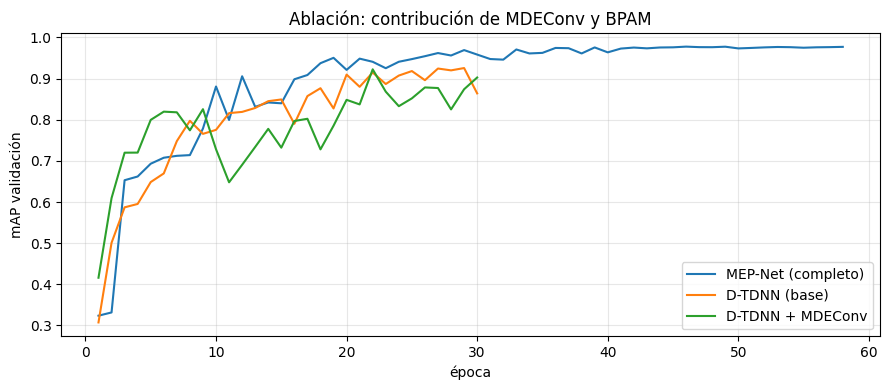

In [23]:
tabla = pd.DataFrame(results).T[["mAP", "F1_macro", "F1_micro", "precision", "recall", "hamming"]]
tabla.index.name = "Modelo"
display(tabla.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for name, h in hists.items():
    ax.plot(h["epoch"], h["val_mAP"], label=name)
ax.set_xlabel("época"); ax.set_ylabel("mAP validación"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Ablación: contribución de MDEConv y BPAM")
plt.tight_layout(); plt.show()

---
## 10. Análisis de resultados y errores

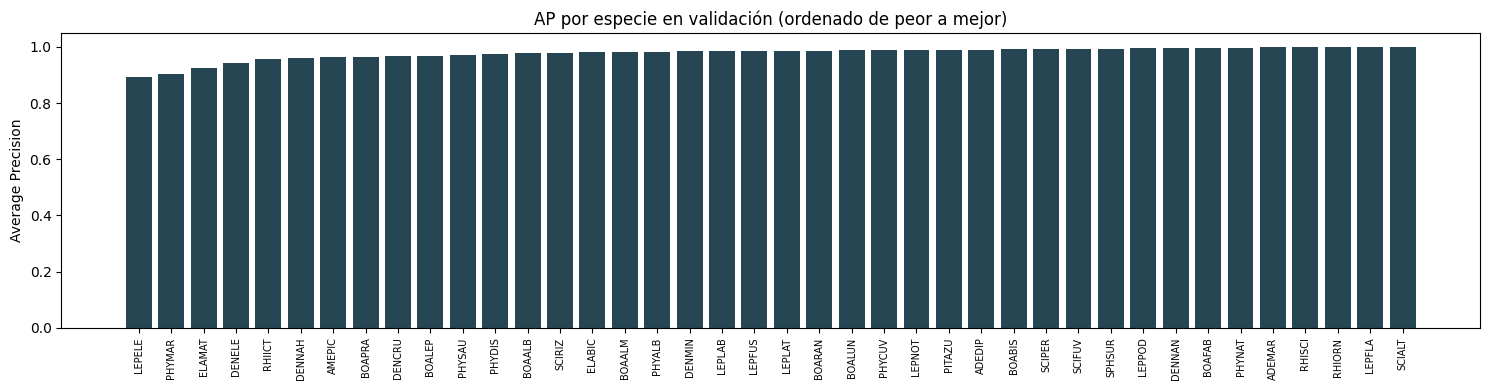

5 especies más difíciles:


,clase,positivos_val,AP,F1,FP,FN
30,LEPELE,9,0.891088,0.800000,0,3
15,PHYMAR,44,0.903535,0.826087,10,6
28,ELAMAT,83,0.923193,0.864198,9,13
40,DENELE,29,0.942569,0.812500,9,3
5,RHIICT,56,0.955377,0.963636,1,3


5 especies mejor reconocidas:


,clase,positivos_val,AP,F1,FP,FN
34,ADEMAR,98,0.998517,0.965174,6,1
31,RHISCI,1,1.000000,1.000000,0,0
37,RHIORN,5,1.000000,1.000000,0,0
38,LEPFLA,2,1.000000,1.000000,0,0
41,SCIALT,43,1.000000,1.000000,0,0


In [24]:
# --- Desempeño por clase (MEP-Net) ---
y_pred_val = (prob_val >= BEST_TH).astype(int)
per_class = pd.DataFrame({
    "clase": CLASS_NAMES,
    "positivos_val": y_val_true.sum(axis=0).astype(int),
    "AP": [average_precision_score(y_val_true[:, j], prob_val[:, j]) if y_val_true[:, j].sum() > 0 else np.nan
           for j in range(N_CLASSES)],
    "F1": f1_score(y_val_true, y_pred_val, average=None, zero_division=0),
    "FP": ((y_pred_val == 1) & (y_val_true == 0)).sum(axis=0),
    "FN": ((y_pred_val == 0) & (y_val_true == 1)).sum(axis=0),
}).sort_values("AP")
fig, ax = plt.subplots(figsize=(15, 4))
pc = per_class.dropna(subset=["AP"])
ax.bar(pc["clase"], pc["AP"], color="#264653")
ax.set_xticklabels(pc["clase"], rotation=90, fontsize=7); ax.set_ylabel("Average Precision")
ax.set_title("AP por especie en validación (ordenado de peor a mejor)")
plt.tight_layout(); plt.show()
print("5 especies más difíciles:");  display(per_class.head(5))
print("5 especies mejor reconocidas:"); display(per_class.dropna(subset=['AP']).tail(5))

In [25]:
# --- Confusiones entre pares: ¿qué especie se predice cuando falta la real? ---
# Para cada FN de la clase j, contamos qué clases fueron FP en el mismo clip.
conf = np.zeros((N_CLASSES, N_CLASSES))
for i in range(len(y_val_true)):
    fn = np.where((y_val_true[i] == 1) & (y_pred_val[i] == 0))[0]
    fp = np.where((y_val_true[i] == 0) & (y_pred_val[i] == 1))[0]
    for a in fn:
        for b in fp:
            conf[a, b] += 1
pairs = [(CLASS_NAMES[a], CLASS_NAMES[b], int(conf[a, b]))
         for a in range(N_CLASSES) for b in range(N_CLASSES) if conf[a, b] > 0]
pairs = sorted(pairs, key=lambda t: -t[2])[:10]
print("Top confusiones (especie real omitida -> especie predicha en su lugar):")
for a, b, c in pairs: print(f"  {a:30s} -> {b:30s}  ({c} clips)")
if not pairs: print("  (sin confusiones cruzadas relevantes con el umbral actual)")

Top confusiones (especie real omitida -> especie predicha en su lugar):
  PHYALB                         -> SPHSUR                          (17 clips)
  LEPPOD                         -> SPHSUR                          (15 clips)
  DENMIN                         -> SPHSUR                          (12 clips)
  BOABIS                         -> SPHSUR                          (10 clips)
  BOAALB                         -> SPHSUR                          (10 clips)
  PITAZU                         -> SPHSUR                          (10 clips)
  DENNAN                         -> SPHSUR                          (9 clips)
  BOAFAB                         -> SPHSUR                          (8 clips)
  PHYCUV                         -> SPHSUR                          (8 clips)
  SCIFUV                         -> SPHSUR                          (8 clips)


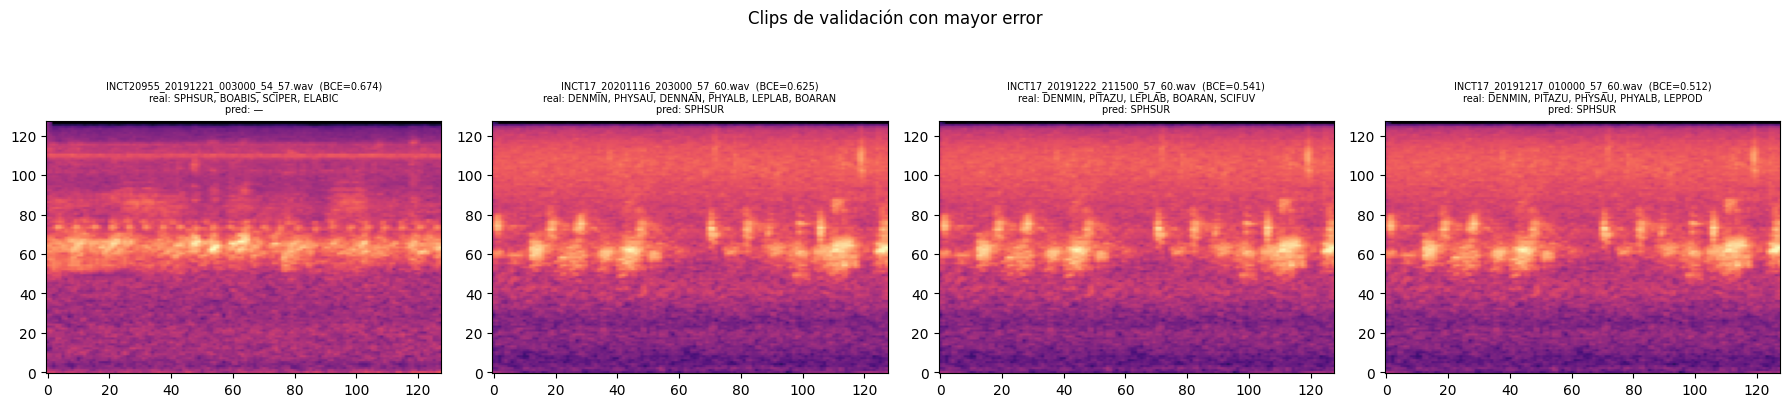


BCE medio según nº de especies en el clip:
  0 especies: BCE 0.0016  (4533 clips)
  1 especies: BCE 0.0080  (2586 clips)
  2 especies: BCE 0.0120  (2060 clips)
  3 especies: BCE 0.0140  (1742 clips)
  4 especies: BCE 0.0179  (995 clips)
  5 especies: BCE 0.0313  (335 clips)
  6 especies: BCE 0.0394  (145 clips)
  7 especies: BCE 0.0241  (40 clips)
  8 especies: BCE 0.0459  (2 clips)


In [26]:
# --- Clips con mayor error (peor BCE) y sus espectrogramas ---
eps = 1e-7
bce_clip = -(y_val_true * np.log(prob_val + eps) + (1 - y_val_true) * np.log(1 - prob_val + eps)).mean(axis=1)
worst = np.argsort(bce_clip)[::-1][:4]
fig, axes = plt.subplots(1, len(worst), figsize=(4.5*len(worst), 3.8))
for ax, i in zip(np.atleast_1d(axes), worst):
    m = get_mel_cached(val_files[i], "train")
    ax.imshow(m, aspect="auto", origin="lower", cmap="magma")
    reales = [CLASS_NAMES[j] for j in range(N_CLASSES) if y_val_true[i, j] == 1]
    preds  = [CLASS_NAMES[j] for j in range(N_CLASSES) if y_pred_val[i, j] == 1]
    ax.set_title(f"{Path(val_files[i]).name}  (BCE={bce_clip[i]:.3f})\nreal: {', '.join(reales) or '—'}\npred: {', '.join(preds) or '—'}", fontsize=7)
plt.suptitle("Clips de validación con mayor error", y=1.06)
plt.tight_layout(); plt.show()

# Relación error vs nº de etiquetas y rareza de la clase
n_lab_val = y_val_true.sum(axis=1)
print("\nBCE medio según nº de especies en el clip:")
for k in np.unique(n_lab_val.astype(int)):
    sel = n_lab_val == k
    print(f"  {k} especies: BCE {bce_clip[sel].mean():.4f}  ({sel.sum()} clips)")

---
## 11. Predicciones sobre el test set

Generamos `predicciones_test.csv` con el mismo formato de `train.csv`: nombre de archivo + 42 columnas binarias (umbral óptimo de validación). Añadimos también las probabilidades (`predicciones_test_probs.csv`) por si la evaluación usa métricas basadas en ranking.

In [27]:
dl_test = DataLoader(BirdClips(test_files, None, "test"), batch_size=BATCH_SIZE,
                     shuffle=False, num_workers=NUM_WORKERS)
mepnet.eval(); all_probs, all_names = [], []
with torch.no_grad():
    for x, names in dl_test:
        all_probs.append(torch.sigmoid(mepnet(x.to(DEVICE))).cpu().numpy())
        all_names += list(names)
probs_test = np.vstack(all_probs)
sub_bin = pd.DataFrame(np.c_[all_names, (probs_test >= BEST_TH).astype(int)], columns=[FILE_COL] + CLASS_NAMES)
sub_prob = pd.DataFrame(np.c_[all_names, probs_test.round(5)], columns=[FILE_COL] + CLASS_NAMES)
sub_bin.to_csv("predicciones_test.csv", index=False)
sub_prob.to_csv("predicciones_test_probs.csv", index=False)
print(f"{len(sub_bin)} predicciones guardadas en predicciones_test.csv (umbral {BEST_TH:.3f})")
print(f"Especies predichas por clip (media): {(probs_test >= BEST_TH).sum(axis=1).mean():.2f}")
sub_bin.head()

31187 predicciones guardadas en predicciones_test.csv (umbral 0.200)
Especies predichas por clip (media): 1.50


,filename,SPHSUR,BOABIS,SCIPER,DENNAH,LEPLAT,RHIICT,BOALEP,BOAFAB,PHYCUV,...,SCINAS,LEPNOT,ADEMAR,BOAALM,PHYDIS,RHIORN,LEPFLA,SCIRIZ,DENELE,SCIALT
0,INCT17_20191125_040000_0_3.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,INCT17_20191125_040000_10_13.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,INCT17_20191125_040000_11_14.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,INCT17_20191125_040000_12_15.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,INCT17_20191125_040000_13_16.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## 12. Conclusiones, diferencias con el paper y limitaciones

**Sobre el método.** MEP-Net combina tres ideas complementarias: (i) el backbone D-TDNN modela la dinámica temporal del canto con conexiones densas y pocos parámetros; (ii) MDEConv inyecta información de **gradiente** tiempo-frecuencia en 4 direcciones, realzando detalles finos que el ruido de fondo tiende a enmascarar; (iii) BPAM pondera **parches** del espectrograma a dos escalas y filtra los irrelevantes por similitud con un embedding de tarea. La ablación (Sección 9) permite cuantificar la contribución de cada módulo en nuestro dataset.

**Diferencias importantes respecto a la propuesta original** (además de las adaptaciones multi-label de la Sección 2):
- Interfaz 2D→1D entre BPAM y D-TDNN definida por nosotros (pooling de frecuencia 128→4 y aplanado canales×bandas), pues el paper no la especifica.
- Menos épocas que el paper (200) por límite de cómputo, con early stopping y scheduler; el paper no usa augmentación y nosotros añadimos enmascaramiento tiempo/frecuencia ligero.
- Umbral de decisión ajustado en validación (necesario en multi-label; el paper usa argmax).
- Dimensiones de canales del tramo 2D (32) elegidas para ajustarse a una GPU de 4 GB manteniendo el número de parámetros cercano al reportado (~3M).

**Limitaciones observadas:** clases con muy pocos ejemplos obtienen AP bajo e inestable; clips con varias especies solapadas concentran el error (ver Sección 10); el umbral global podría refinarse por clase. Trabajo futuro: umbrales por clase, pérdida focal o ponderada por frecuencia de clase, y mixup de audio para clases raras.

**Reproducibilidad:** semilla 42 en split, baraje e inicialización; checkpoints en `checkpoints/`; espectrogramas cacheados en `mel_cache/`.